# Avellaneda-Stoikov Strategy

## Lighter backtesting

In [1]:
import sys
import math
import numpy as np
from pathlib import Path
import os
import itertools
from tqdm.notebook import tqdm

# Корень репо = ближайший предок cwd с .git. Кладём на путь и его (для backtesting),
# и research/ (для tools) — до импортов ниже.
here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / ".git").exists())
for path in (str(ROOT), str(ROOT / "research")):
    if path not in sys.path:
        sys.path.insert(0, path)

from tools import ROOT   # переопределяет ROOT корректным путём из tools/__init__.py
from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

CAPITAL = 2000.0  # USD

In [2]:
import pandas as pd

os.makedirs("results", exist_ok=True)


def grid_search(strategy_cls, param_grid, backtester, feed, fixed_params=None, capital=CAPITAL):
    """Grid search over `param_grid`.

    Each row = the parameter combo + EVERY numeric metric from
    ``BacktestResult(prefix, capital).summary()`` — pulled as one dict merge,
    not a hand-picked list, so new metrics (capture_yield, net_edge, jumps, …)
    show up in the frame automatically. Returns a tidy DataFrame (params first).
    """
    fixed_params = fixed_params or {}
    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    rows   = []

    for combo in tqdm(combos, desc="grid_search"):
        params = dict(zip(keys, combo)) | fixed_params
        prefix = f"/tmp/_gs_{abs(hash(str(sorted(params.items()))))}"
        backtester.run(strategy_cls(**params), feed, output_path=prefix)

        metrics = BacktestResult(prefix, capital=capital).summary()
        rows.append({**params, **metrics})          # params first, then all metrics

        for suffix in ("_pnl", "_quotes", "_fills"):
            try: os.remove(f"{prefix}{suffix}.csv")
            except: pass

    return pd.DataFrame(rows)

In [3]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q):
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        return [
            ("bid", r - half_spread, self.Q),
            ("ask", r + half_spread, self.Q),
        ]

In [4]:
days = range(13, 24)          # 14, 15, 16, 17 июля
hours = range(0, 24)

lob_paths = []
trades_paths = []

for d in days:
    day_str = f"202607{d:02d}"
    for h in hours:
        lob_paths.append(ROOT / f"data/lighter/TAO/lob/{day_str}/{h:02d}.parquet")
        trades_paths.append(ROOT / f"data/lighter/TAO/trades/{day_str}/{h:02d}.jsonl.zst")

print(f"Всего файлов LOB: {len(lob_paths)}")
print(f"Всего файлов trades: {len(trades_paths)}")

Всего файлов LOB: 264
Всего файлов trades: 264


In [5]:
feed = LighterFeed(lob_paths, trades_paths)
feed

LighterFeed(depth=3, lob=6,716,540 snapshots [2026-07-13 00:00:00.043000 → 2026-07-23 23:59:59.911000], trades=16,102 [2026-07-12 23:10:32.212000 → 2026-07-23 23:59:13.924000])

In [6]:
# Calibrate AS inputs straight from the loaded feed (arrays, not CSV).
mid    = (feed.bid_px[:, 0] + feed.ask_px[:, 0]) / 2.0
mid_ts = pd.to_datetime(feed.lob_ts, unit="us")
tr_ts  = pd.to_datetime(feed.trade_ts, unit="us")

# sigma — std of 1-sec mid increments (price / sqrt-sec)
mid_1s    = pd.Series(mid, index=mid_ts).resample("1s").last().ffill()
sigma_hat = float(mid_1s.diff().dropna().std())

# A — mean trade arrival rate (trades / sec)
span_sec = (tr_ts.max() - tr_ts.min()).total_seconds()
A_hat    = len(feed.trade_ts) / span_sec

# kappa — exp decay from mean |trade_price - mid|; mid aligned to each trade (backward)
aligned = pd.merge_asof(
    pd.DataFrame({"price": feed.trade_price}, index=tr_ts).sort_index(),
    pd.DataFrame({"mid": mid}, index=mid_ts).sort_index(),
    left_index=True, right_index=True, direction="backward",
).dropna()
delta     = (aligned["price"] - aligned["mid"]).abs()
kappa_hat = 1.0 / float(delta[delta > 0].mean())

print(f"sigma = {sigma_hat:.3e}   (mid volatility, price / sqrt-sec)")
print(f"A     = {A_hat:.5f}   (mean trade arrival rate, trades/sec)")
print(f"kappa = {kappa_hat:.3e}   (exp decay rate; mean |trade - mid| = {1/kappa_hat:.3e})")

sigma = 1.969e-02   (mid volatility, price / sqrt-sec)
A     = 0.01689   (mean trade arrival rate, trades/sec)
kappa = 2.404e+01   (exp decay rate; mean |trade - mid| = 4.160e-02)


In [7]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 3
lob snapshots : 6,716,540  (crossed/locked: 0)
trades        : 16,102  (sells: 8,349)
invariants OK


In [8]:
bt = Backtester(log_interval_sec=10.0)

sweep = grid_search(
    AvellanedaStoikov,
    {
        "sigma": [2.355e-2],
        "kappa": [2.306e+1],
        "gamma": [0.02, 0.05],
        "T":     [600, 2000],
        "Q":     [0.01, 0.1],
    },
    bt,
    feed,
)

grid_search:   0%|          | 0/8 [00:00<?, ?it/s]

In [9]:
sweep.sort_values("spread_capture_usd", ascending=False).columns

Index(['sigma', 'kappa', 'gamma', 'T', 'Q', 'total_pnl', 'sharpe_annualized',
       'max_drawdown', 'spread_capture_usd', 'inv_mtm_usd', 'identity_gap_usd',
       'inv_mtm_grid_error_usd', 'spread_capture_pct', 'inv_mtm_pct',
       'net_edge_per_fill_bps', 'markout_30s_bps', 'net_edge_ci_lo',
       'net_edge_ci_hi', 'capture_share_of_variance', 'corr_hourly_pnl_return',
       'n_fills', 'n_bid_fills', 'n_ask_fills', 'fill_imbalance', 'turnover',
       'turnover_usd', 'capture_yield_bps', 'avg_inventory', 'std_inventory',
       'max_abs_inventory', 'mean_abs_inventory', 'p90_abs_inventory',
       'time_at_90pct_max_inv_pct', 'median_excursion_min',
       'zero_crossings_per_day', 'worst_unrealized_usd', 'n_jumps',
       'pnl_in_jump_windows_usd', 'pnl_in_jump_windows_pct', 'worst_hour_usd',
       'p5_hourly_usd', 'two_sided_uptime_pct', 'quote_updates_min_p50',
       'quote_updates_min_p95'],
      dtype='object')

In [10]:
sweep.sort_values("sharpe_annualized", ascending=False)[
    ["total_pnl", "spread_capture_usd", "sharpe_annualized", "max_drawdown", 
     "net_edge_ci_lo", "corr_hourly_pnl_return", "n_fills", "turnover_usd", 
     "avg_inventory", "max_abs_inventory", "mean_abs_inventory",
     "pnl_in_jump_windows_usd", "worst_hour_usd", "capture_yield_bps"
    ]
].head(15)

,total_pnl,spread_capture_usd,sharpe_annualized,max_drawdown,net_edge_ci_lo,corr_hourly_pnl_return,n_fills,turnover_usd,avg_inventory,max_abs_inventory,mean_abs_inventory,pnl_in_jump_windows_usd,worst_hour_usd,capture_yield_bps
6,7.208591,0.972133,8.954211,-3.389342,1.317004,-0.257783,2147,4028.995514,-0.026023,0.756,0.165022,3.582353,-1.079730,2.412843
7,15.786231,7.461467,8.475959,-5.288564,1.118529,-0.026737,2097,34079.158617,-0.021750,3.101,0.351779,5.562792,-3.379872,2.189452
3,26.198173,9.183433,7.123375,-13.117491,1.130066,-0.046367,2840,45317.272094,-0.005137,4.999,0.742771,12.622793,-7.614904,2.026475
1,43.617662,10.637117,5.726372,-33.501415,0.983313,-0.070434,3363,53338.088155,0.258274,7.468,1.564003,19.896977,-8.396484,1.994282
5,22.871360,9.352036,5.438325,-16.121525,0.937424,-0.048316,2922,46608.588565,0.066954,5.507,0.814254,7.959852,-4.141881,2.006505
2,7.328149,1.212671,4.049054,-8.462590,1.347523,-0.210275,2960,5500.263137,-0.012068,1.219,0.391295,4.070963,-2.668585,2.204751
4,7.057815,1.250684,3.051671,-11.142596,1.192453,-0.277169,3105,5753.450946,-0.082703,1.385,0.524805,5.113141,-3.677811,2.173797
0,8.072153,1.350613,1.869818,-20.194435,1.119148,-0.422422,3519,6482.844458,-0.450588,2.314,1.003685,8.821257,-7.311700,2.083365


In [11]:
best = sweep.sort_values("sharpe_annualized", ascending=False).iloc[0]
best_params = {k: best[k] for k in ["sigma", "kappa", "gamma", "T", "Q"]}
print("Best params:", best_params)

Best params: {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.05), 'T': np.float64(2000.0), 'Q': np.float64(0.01)}


In [12]:
# params = best_params
params = {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.02), 'T': np.float64(600.0), 'Q': np.float64(0.1)}
prefix = "/tmp/_lighter_dod"

bt = Backtester(log_interval_sec=1.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [13]:
s = BacktestResult(prefix, capital=CAPITAL)
display(s.summary_df())

value  \
group     metric                                               
PnL       total_pnl ($)                             +43.6177   
          sharpe_annualized                            +5.95   
          max_drawdown ($)                          -33.7189   
          spread_capture ($)                        +10.6371   
          spread_capture (% of total)                +24.39%   
          capture_yield (bps)                          +1.99   
          inventory_mtm ($)                         +32.9805   
          inventory_mtm (% of total)                 +75.61%   
          identity_gap ($)                           +0.0000   
          inv_mtm_grid_error ($)                     -4.6109   
          net_edge_per_fill (bps)                      +1.43   
          net_edge CI95 [lo, hi]              [+0.98, +1.82]   
          markout_30s (bps)                            -0.59   
          capture_share_of_variance                  +0.9420   
          corr(hourly_pnl, hourly_return)            -0.0644   
Fills     n_fills                                      3,363   
          n_bid_fills                                  1,736   
          n_ask_fills                                  1,627   
          fill_imbalance                             +0.0324   
Inventory avg_inventory                              +0.2583   
          std_inventory                               2.0665   
          max_abs_inventory                           7.4680   
          turnover ($)                            +53,338.09   
          mean |inv|                                  1.5640   
          p90 |inv|                                   3.5000   
          zero_crossings / day                        3.4545   
          median_excursion (min)                     86.1417   
          worst_unrealized ($)                      -15.8399   
          time at ≥90% max|inv| (%)                     0.85   
Tails     n_jumps                                        117   
          pnl_in_jump_windows ($)                   +18.3527   
          pnl_in_jump_windows (% of |total|)         +42.08%   
          worst_hour ($)                             -8.4814   
          p5_hourly ($)                              -2.8825   
Ops       two_sided_uptime (%)                         99.97   
          quote_updates/min p50                         8.00   
          quote_updates/min p95                        13.00   

                                                                                           note  
group     metric                                                                                 
PnL       total_pnl ($)                                                                          
          sharpe_annualized                                                                      
          max_drawdown ($)                                                                       
          spread_capture ($)                                                                     
          spread_capture (% of total)                                                            
          capture_yield (bps)                                                                    
          inventory_mtm ($)                                                                      
          inventory_mtm (% of total)                                                             
          identity_gap ($)                                                                       
          inv_mtm_grid_error ($)                                                                 
          net_edge_per_fill (bps)                                                                
          net_edge CI95 [lo, hi]                                                                 
          markout_30s (bps)                   coarse quote log (median 6.2s > 1s grid); unde...  
          capture_share_of_variance                                                     

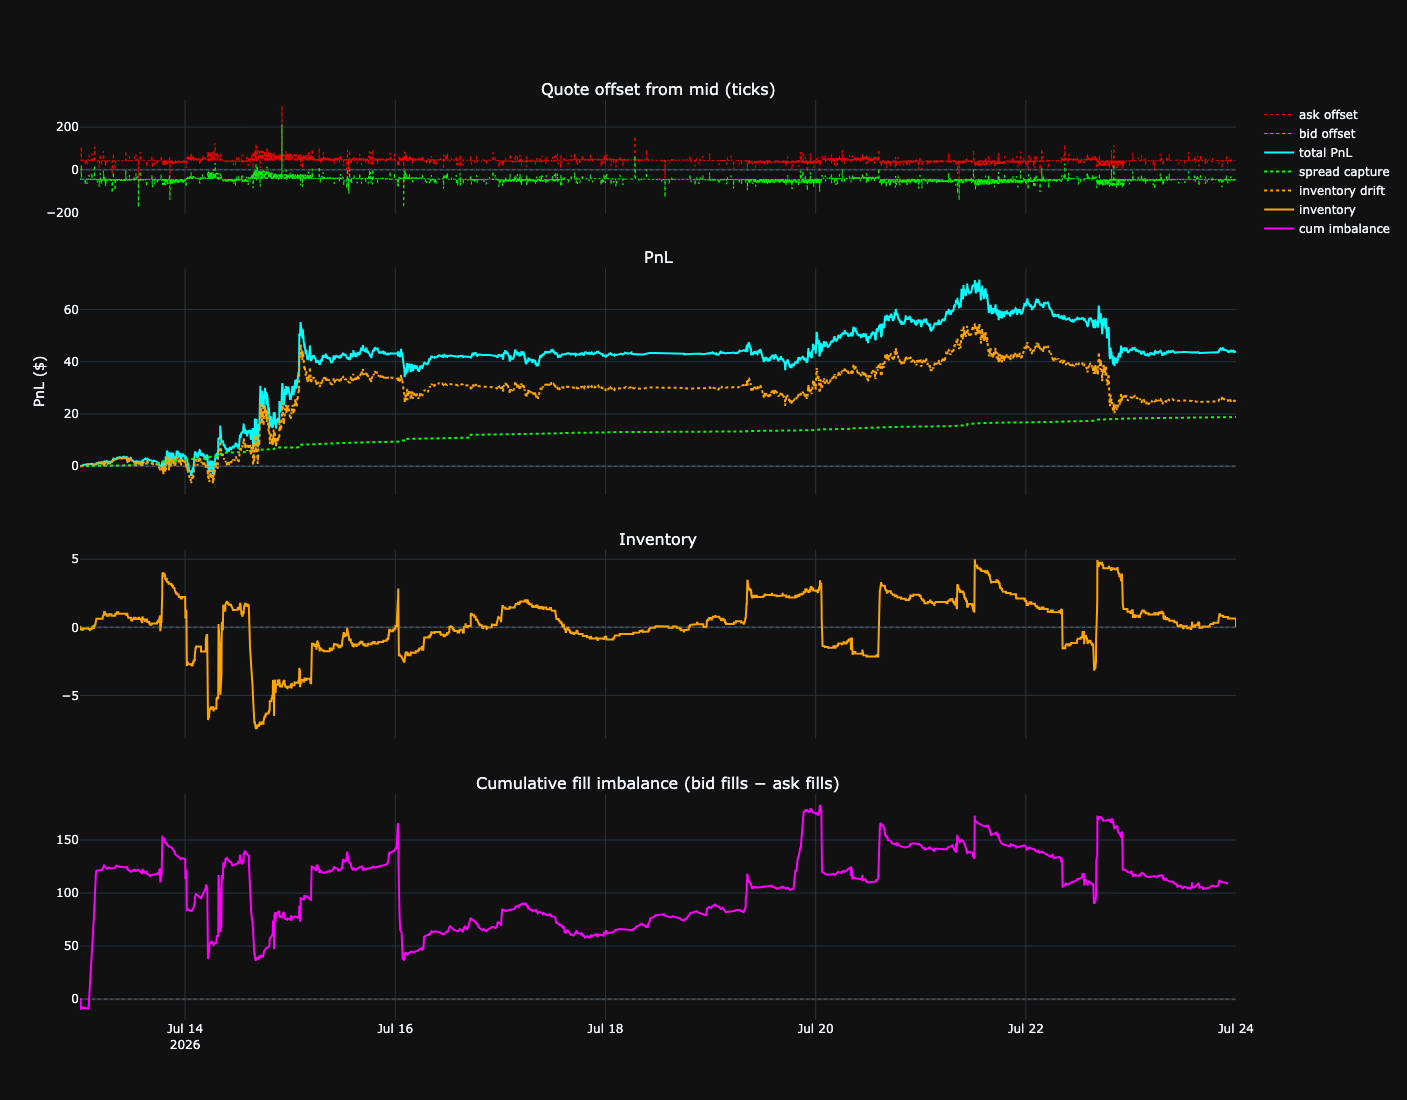

In [15]:
s.plot(tick_size=1e-3).show()